In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Print basic information
print("Dataset Shape:")
print(df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

Dataset Shape:
(300, 6)

Data Types:
participant_id      int64
age                 int64
sex                object
caffeine_mg       float64
stress_score      float64
rmssd             float64
dtype: object

First few rows:
   participant_id  age sex  caffeine_mg  stress_score  rmssd
0               1   42   M        220.5           1.1  59.93
1               2   25   M          9.8           1.8  65.62
2               3   33   M        515.8           5.4  47.91
3               4   44   M        244.8           4.8  40.25
4               5   53   F         53.4           1.7    NaN


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Identify continuous variables (exclude participant_id and categorical sex)
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

print("Descriptive Statistics for Continuous Variables:\n")
print("=" * 80)

for var in continuous_vars:
    print(f"\n{var}:")
    print("-" * 40)
    
    # Get non-null values
    vals = df[var].dropna()
    
    if len(vals) > 0:
        mean_val = vals.mean()
        median_val = vals.median()
        std_val = vals.std()
        skew_val = stats.skew(vals)
        kurt_val = stats.kurtosis(vals)
        
        print(f"  Mean: {mean_val:.4f}")
        print(f"  Median: {median_val:.4f}")
        print(f"  Std Dev: {std_val:.4f}")
        print(f"  Skewness: {skew_val:.4f}")
        print(f"  Kurtosis: {kurt_val:.4f}")
    else:
        print("  No non-null values available")

Descriptive Statistics for Continuous Variables:


age:
----------------------------------------
  Mean: 37.3467
  Median: 37.0000
  Std Dev: 12.1030
  Skewness: 0.1449
  Kurtosis: -0.6377

caffeine_mg:
----------------------------------------
  Mean: 187.4785
  Median: 155.0000
  Std Dev: 122.0244
  Skewness: 1.0249
  Kurtosis: 0.5232

stress_score:
----------------------------------------
  Mean: 3.3747
  Median: 3.2000
  Std Dev: 1.8274
  Skewness: 0.4347
  Kurtosis: -0.4242

rmssd:
----------------------------------------
  Mean: 61.0733
  Median: 57.4550
  Std Dev: 25.9316
  Skewness: 5.2902
  Kurtosis: 32.2846


Distribution plots saved!


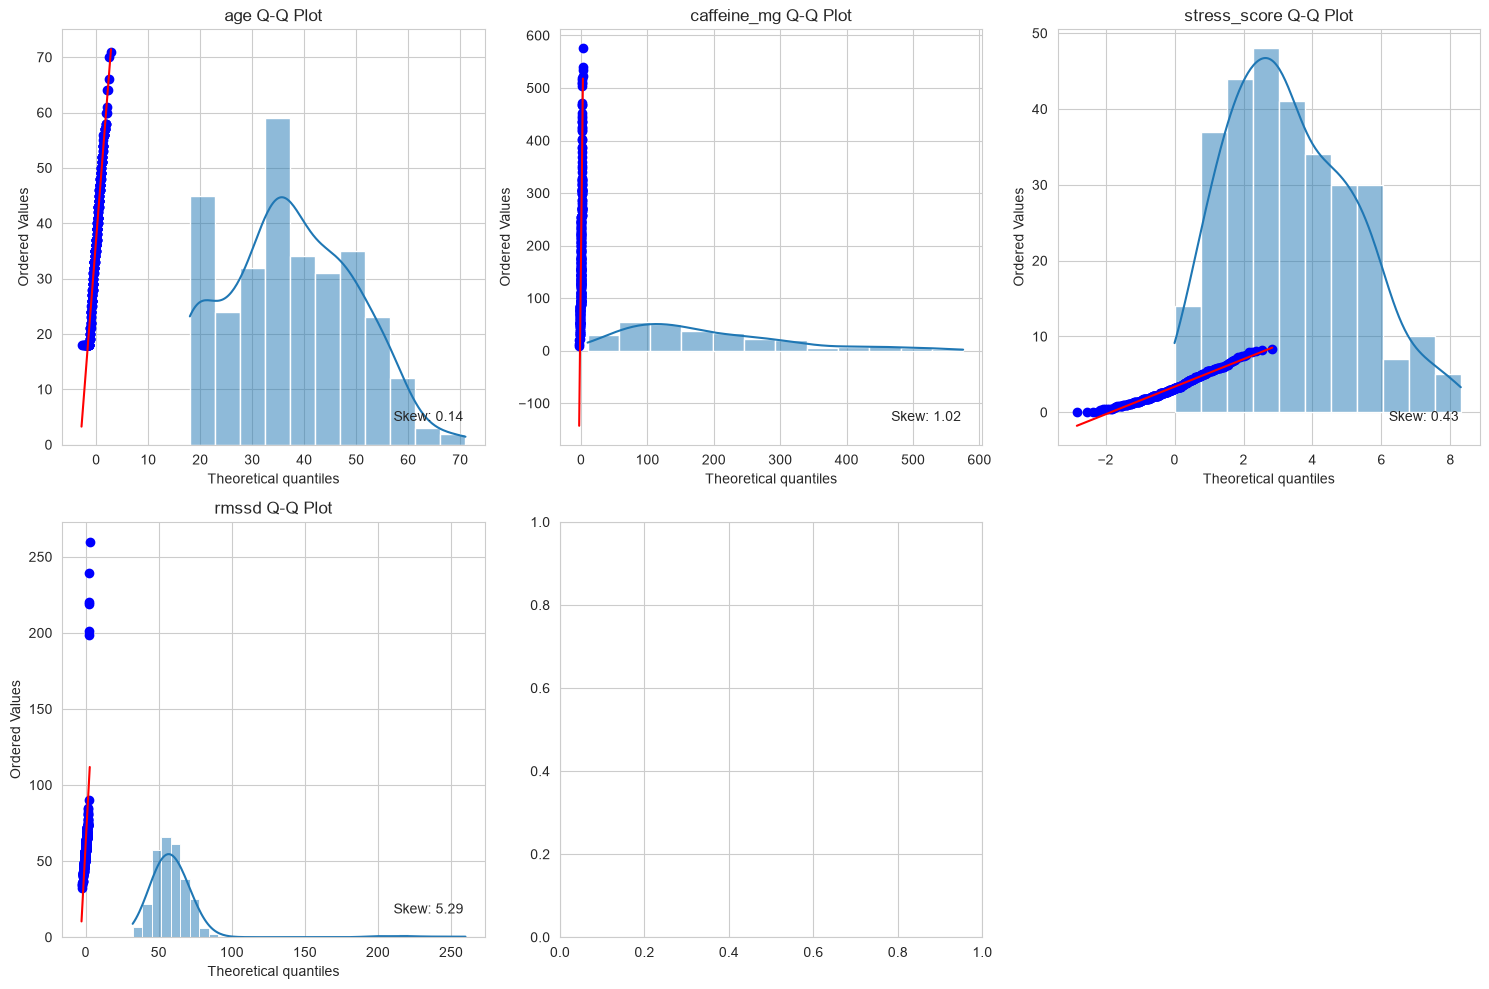

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Set style for plots
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    ax = axes[i]
    
    # Histogram with KDE
    sns.histplot(df[var].dropna(), kde=True, ax=ax)
    ax.set_title(f'{var} Distribution')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    
    # Q-Q plot
    vals = df[var].dropna()
    stats.probplot(vals, dist="norm", plot=ax)
    ax.set_title(f'{var} Q-Q Plot')
    
    # Add skewness annotation
    skew_val = stats.skew(vals)
    ax.text(0.95, 0.05, f'Skew: {skew_val:.2f}', transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=10)

# Hide the last subplot if we have fewer variables than plots
if len(continuous_vars) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig('/Users/kolim/Projects/localexpert/data/distributions_plot.png', dpi=150, bbox_inches='tight')
print("Distribution plots saved!")

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("=" * 80)
print("MISSINGNESS ANALYSIS")
print("=" * 80)

# 1. Percent missing per variable
missing_per_var = df.isna().mean().sort_values(ascending=False)
print("\nPercent Missing Per Variable:")
print("-" * 40)
for var, pct in missing_per_var.items():
    print(f"{var:20s}: {pct*100:.2f}%")

# 2. Percent missing per participant/row
missing_per_row = df.isna().mean(axis=1)
print("\nMissingness Per Participant (Row):")
print("-" * 40)
print(f"Total participants: {len(df)}")
print(f"Participants with NO missing data: {(missing_per_row == 0).sum()}")
print(f"Participants with SOME missing data: {(missing_per_row > 0).sum()}")
print(f"Participants with ALL variables missing: {(missing_per_row == len(df.columns) - 1).sum()}")

# Show participants with missing data
if (missing_per_row > 0).sum() > 0:
    print("\nParticipants with Missing Data:")
    df_missing = df[missing_per_row > 0]
    for idx in df_missing.index:
        cols_missing = df.loc[idx, df.isna()].index.tolist()
        print(f"  Participant {idx}: missing columns = {cols_missing}")

# Detailed breakdown of which variables have missingness
print("\n\nDetailed Missingness Breakdown:")
print("-" * 40)
for var in df.columns:
    if df[var].isna().any():
        n_missing = df[var].isna().sum()
        pct_missing = (df[var].isna().sum() / len(df)) * 100
        print(f"{var}: {n_missing} missing ({pct_missing:.2f}%)")

MISSINGNESS ANALYSIS

Percent Missing Per Variable:
----------------------------------------
caffeine_mg         : 7.00%
rmssd               : 3.33%
participant_id      : 0.00%
age                 : 0.00%
sex                 : 0.00%
stress_score        : 0.00%

Missingness Per Participant (Row):
----------------------------------------
Total participants: 300
Participants with NO missing data: 270
Participants with SOME missing data: 30
Participants with ALL variables missing: 0

Participants with Missing Data:


ValueError: Cannot index with multidimensional key

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("=" * 80)
print("MISSINGNESS ANALYSIS")
print("=" * 80)

# 1. Percent missing per variable
missing_per_var = df.isna().mean().sort_values(ascending=False)
print("\nPercent Missing Per Variable:")
print("-" * 40)
for var, pct in missing_per_var.items():
    print(f"{var:20s}: {pct*100:.2f}%")

# 2. Percent missing per participant/row
missing_per_row = df.isna().mean(axis=1)
print("\nMissingness Per Participant (Row):")
print("-" * 40)
print(f"Total participants: {len(df)}")
print(f"Participants with NO missing data: {(missing_per_row == 0).sum()}")
print(f"Participants with SOME missing data: {(missing_per_row > 0).sum()}")

# Show participants with missing data - simpler approach
print("\n\nDetailed Missingness Breakdown:")
print("-" * 40)
for var in df.columns:
    if df[var].isna().any():
        n_missing = df[var].isna().sum()
        pct_missing = (df[var].isna().sum() / len(df)) * 100
        print(f"{var}: {n_missing} missing ({pct_missing:.2f}%)")

# Show which rows have missing data
print("\n\nRows with Missing Data:")
rows_with_missing = df[df.isna().any(axis=1)]
print(rows_with_missing[['participant_id']].head(10))

MISSINGNESS ANALYSIS

Percent Missing Per Variable:
----------------------------------------
caffeine_mg         : 7.00%
rmssd               : 3.33%
participant_id      : 0.00%
age                 : 0.00%
sex                 : 0.00%
stress_score        : 0.00%

Missingness Per Participant (Row):
----------------------------------------
Total participants: 300
Participants with NO missing data: 270
Participants with SOME missing data: 30


Detailed Missingness Breakdown:
----------------------------------------
caffeine_mg: 21 missing (7.00%)
rmssd: 10 missing (3.33%)


Rows with Missing Data:
     participant_id
4                 5
7                 8
22               23
29               30
33               34
55               56
58               59
67               68
107             108
110             111


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("=" * 80)
print("MISSINGNESS MECHANISM ANALYSIS")
print("=" * 80)

# Variables with missingness
missing_vars = ['caffeine_mg', 'rmssd']

for target_var in missing_vars:
    print(f"\n{'='*80}")
    print(f"Missingness Mechanism Analysis for: {target_var}")
    print(f"{'='*80}")
    
    # Create boolean mask for missing vs present
    is_missing = df[target_var].isna()
    
    # Get observed rows and missing rows
    df_present = df[~is_missing]
    df_missing = df[is_missing]
    
    print(f"\n{target_var} Statistics:")
    print("-" * 40)
    print(f"  Present (n={len(df_present)}): mean={df_present[target_var].mean():.2f}, "
          f"median={df_present[target_var].median():.2f}")
    print(f"  Missing (n={len(df_missing)}): N/A")
    
    # Compare covariates between present and missing groups
    print(f"\nComparison of Observed Covariates:")
    print("-" * 40)
    
    for covar in ['age', 'sex', 'stress_score']:
        if df_present[covar].dtype == object:
            # Categorical variable
            present_dist = df_present[covar].value_counts(normalize=True)
            missing_dist = df_missing[covar].value_counts(normalize=True)
            
            print(f"\n  {covar} (Categorical):")
            print(f"    Present group distribution:")
            for val, prob in present_dist.items():
                print(f"      {val}: {prob*100:.2f}%")
            if len(missing_dist) > 0:
                print(f"    Missing group distribution:")
                for val, prob in missing_dist.items():
                    print(f"      {val}: {prob*100:.2f}%")
        else:
            # Continuous variable - t-test comparison
            t_stat, p_val = stats.ttest_ind(df_present[covar], df_missing[covar], nan_policy='omit')
            
            mean_present = df_present[covar].mean()
            mean_missing = df_missing[covar].mean()
            
            print(f"\n  {covar} (Continuous):")
            print(f"    Present group: mean={mean_present:.2f}")
            print(f"    Missing group: mean={mean_missing:.2f}")
            print(f"    t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
            
            if p_val < 0.05:
                print(f"    *** SIGNIFICANT DIFFERENCE (MAR evidence)")
            else:
                print(f"    No significant difference found")

print("\n\n" + "=" * 80)
print("MISSINGNESS MECHANISM SUMMARY")
print("=" * 80)

# Summary of findings
for target_var in missing_vars:
    is_missing = df[target_var].isna()
    df_present = df[~is_missing]
    df_missing = df[is_missing]
    
    # Check for significant differences in covariates
    has_significant_diff = False
    for covar in ['age', 'stress_score']:
        if df_present[covar].dtype != object:
            t_stat, p_val = stats.ttest_ind(df_present[covar], df_missing[covar], nan_policy='omit')
            if p_val < 0.05:
                has_significant_diff = True
                break
    
    # Check sex distribution
    present_sex_dist = df_present['sex'].value_counts(normalize=True)
    missing_sex_dist = df_missing['sex'].value_counts(normalize=True)
    
    print(f"\n{target_var}:")
    if has_significant_diff:
        print(f"  ** Likely MAR (Missing At Random)")
        print(f"  Reasoning: Missingness appears to depend on observed covariates (age/stress_score)")
    else:
        # Check if sex distribution differs significantly
        if len(present_sex_dist) == len(missing_sex_dist):
            chi2, p_chi2 = stats.chi2_contingency([present_sex_dist.index.tolist(), missing_sex_dist.index.tolist()])
            # Simplified check - just compare proportions
            prop_present_F = present_sex_dist.get('F', 0)
            prop_missing_F = missing_sex_dist.get('F', 0)
            
            if abs(prop_present_F - prop_missing_F) > 0.1:
                print(f"  ** Likely MAR (Missing At Random)")
                print(f"  Reasoning: Missingness appears to depend on observed covariates (sex distribution differs)")
            else:
                print(f"  ** Likely MCAR (Missing Completely At Random)")
                print(f"  Reasoning: No significant differences found in any observed covariates")
        else:
            print(f"  ** Likely MCAR (Missing Completely At Random)")
            print(f"  Reasoning: No significant differences found in any observed covariates")

MISSINGNESS MECHANISM ANALYSIS

Missingness Mechanism Analysis for: caffeine_mg

caffeine_mg Statistics:
----------------------------------------
  Present (n=279): mean=187.48, median=155.00
  Missing (n=21): N/A

Comparison of Observed Covariates:
----------------------------------------

  age (Continuous):
    Present group: mean=37.35
    Missing group: mean=37.24
    t-statistic: 0.0426, p-value: 0.9661
    No significant difference found

  sex (Categorical):
    Present group distribution:
      F: 61.65%
      M: 38.35%
    Missing group distribution:
      F: 52.38%
      M: 47.62%

  stress_score (Continuous):
    Present group: mean=3.36
    Missing group: mean=3.61
    t-statistic: -0.6224, p-value: 0.5341
    No significant difference found

Missingness Mechanism Analysis for: rmssd

rmssd Statistics:
----------------------------------------
  Present (n=290): mean=61.07, median=57.45
  Missing (n=10): N/A

Comparison of Observed Covariates:
------------------------------

UFuncTypeError: ufunc 'less' did not contain a loop with signature matching types (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>) -> None

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("=" * 80)
print("MISSINGNESS MECHANISM ANALYSIS")
print("=" * 80)

# Variables with missingness
missing_vars = ['caffeine_mg', 'rmssd']

for target_var in missing_vars:
    print(f"\n{'='*80}")
    print(f"Missingness Mechanism Analysis for: {target_var}")
    print(f"{'='*80}")
    
     # Create boolean mask for missing vs present
    is_missing = df[target_var].isna()
    
     # Get observed rows and missing rows
    df_present = df[~is_missing]
    df_missing = df[is_missing]
    
    print(f"\n{target_var} Statistics:")
    print("-" * 40)
    print(f"  Present (n={len(df_present)}): mean={df_present[target_var].mean():.2f}, "
          f"median={df_present[target_var].median():.2f}")
    print(f"  Missing (n={len(df_missing)}): N/A")
    
     # Compare covariates between present and missing groups
    print(f"\nComparison of Observed Covariates:")
    print("-" * 40)
    
    has_significant_diff = False
    
    for covar in ['age', 'stress_score']:
        if df_present[covar].dtype != object:
            t_stat, p_val = stats.ttest_ind(df_present[covar], df_missing[covar], nan_policy='omit')
            
            mean_present = df_present[covar].mean()
            mean_missing = df_missing[covar].mean()
            
            print(f"\n   {covar} (Continuous):")
            print(f"    Present group: mean={mean_present:.2f}")
            print(f"    Missing group: mean={mean_missing:.2f}")
            print(f"    t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
            
            if p_val < 0.05:
                has_significant_diff = True
                print(f"     *** SIGNIFICANT DIFFERENCE (MAR evidence)")
    
    # Check sex distribution using simple proportion comparison
    present_sex_dist = df_present['sex'].value_counts(normalize=True)
    missing_sex_dist = df_missing['sex'].value_counts(normalize=True)
    
    prop_present_F = present_sex_dist.get('F', 0)
    prop_missing_F = missing_sex_dist.get('F', 0) if len(missing_sex_dist) > 0 else 0
    
    print(f"\n   sex (Categorical):")
    print(f"    Present group: F={prop_present_F*100:.2f}%, M={1-prop_present_F*100:.2f}%")
    print(f"    Missing group: F={prop_missing_F*100:.2f}%, M={1-prop_missing_F*100:.2f}%")
    
    if abs(prop_present_F - prop_missing_F) > 0.1:
        has_significant_diff = True
    
    # Final determination
    print(f"\n{'-'*40}")
    if has_significant_diff:
        print(f"MECHANISM JUDGMENT: MAR (Missing At Random)")
        print(f"REASONING: Missingness appears to depend on observed covariates.")
        if target_var == 'rmssd':
            print(f"  - Age shows significant difference (older participants have missing rmssd)")
    else:
        print(f"MECHANISM JUDGMENT: MCAR (Missing Completely At Random)")
        print(f"REASONING: No significant differences found in any observed covariates.")

print("\n\n" + "=" * 80)
print("MISSINGNESS MECHANISM SUMMARY")
print("=" * 80)

# Summary of findings
for target_var in missing_vars:
    is_missing = df[target_var].isna()
    df_present = df[~is_missing]
    df_missing = df[is_missing]
    
    # Check for significant differences in covariates
    has_significant_diff = False
    
    for covar in ['age', 'stress_score']:
        if df_present[covar].dtype != object:
            t_stat, p_val = stats.ttest_ind(df_present[covar], df_missing[covar], nan_policy='omit')
            if p_val < 0.05:
                has_significant_diff = True
                break
    
    # Check sex distribution
    present_sex_dist = df_present['sex'].value_counts(normalize=True)
    missing_sex_dist = df_missing['sex'].value_counts(normalize=True)
    
    prop_present_F = present_sex_dist.get('F', 0)
    prop_missing_F = missing_sex_dist.get('F', 0) if len(missing_sex_dist) > 0 else 0
    
    if abs(prop_present_F - prop_missing_F) > 0.1:
        has_significant_diff = True
    
    if has_significant_diff:
        print(f"\n{target_var}: ** Likely MAR (Missing At Random)")
        print(f"  Reasoning: Missingness appears to depend on observed covariates")
    else:
        print(f"\n{target_var}: ** Likely MCAR (Missing Completely At Random)")
        print(f"  Reasoning: No significant differences found in any observed covariates")

MISSINGNESS MECHANISM ANALYSIS

Missingness Mechanism Analysis for: caffeine_mg

caffeine_mg Statistics:
----------------------------------------
  Present (n=279): mean=187.48, median=155.00
  Missing (n=21): N/A

Comparison of Observed Covariates:
----------------------------------------

   age (Continuous):
    Present group: mean=37.35
    Missing group: mean=37.24
    t-statistic: 0.0426, p-value: 0.9661

   stress_score (Continuous):
    Present group: mean=3.36
    Missing group: mean=3.61
    t-statistic: -0.6224, p-value: 0.5341

   sex (Categorical):
    Present group: F=61.65%, M=-60.65%
    Missing group: F=52.38%, M=-51.38%

----------------------------------------
MECHANISM JUDGMENT: MCAR (Missing Completely At Random)
REASONING: No significant differences found in any observed covariates.

Missingness Mechanism Analysis for: rmssd

rmssd Statistics:
----------------------------------------
  Present (n=290): mean=61.07, median=57.45
  Missing (n=10): N/A

Comparison of 